## Business Question

Can we identify stores showing abnormal or persistent sales deterioration early enough to support business monitoring and decision-making?

# Sales Risk Monitoring & Scoring System

## Objective

The objective of this analysis is to identify early signals of sales deterioration at the store level
and classify stores according to their level of business risk.

I will try to combines sales momentum, volatility, trend deviation and persistence
of negative performance to produce an interpretable risk assessment and I will give a valid definition for what is 
considered a risky store.

The analysis is performed on weekly sales aggregated at the store level, allowing the system to identify stores that may require further investigation or managerial attention.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/processed/final_df.csv")

In [4]:
# Aggregate sales at store-week level
df_store = (
    df.groupby(["Store", "Date"], as_index=False)["Weekly_Sales"]
      .sum()
      .sort_values(["Store", "Date"])
      .reset_index(drop=True)
)

In [5]:
df_store.head()

,Store,Date,Weekly_Sales
0,1,2010-02-05,1643690.90
1,1,2010-02-12,1641957.44
2,1,2010-02-19,1611968.17
3,1,2010-02-26,1409727.59
4,1,2010-03-05,1554806.68


In [10]:
# Week-over-week sales change for each store - it's the momentum
df_store["WoW_change"] = (
    df_store.groupby("Store")["Weekly_Sales"]
            .pct_change()
)

The 'problem' with WoW is that a single negative week doesn't mean the store is in trouble.
It could be a temporary dip in sales.

We need to look at the trend over multiple weeks to make a determination.
So we introduce the rolling mean (4 weeks - a month circa).

In [12]:
df_store["Rolling_4W_Sales"] = (
    df_store.groupby("Store")["Weekly_Sales"]
            .transform(lambda x: x.rolling(window=4).mean()))

In [8]:
df_store.head()

,Store,Date,Weekly_Sales,WoW_change,Rolling_4W_Sales
0,1,2010-02-05,1643690.90,NaN,NaN
1,1,2010-02-12,1641957.44,-0.001055,NaN
2,1,2010-02-19,1611968.17,-0.018264,NaN
3,1,2010-02-26,1409727.59,-0.125462,1576836.025
4,1,2010-03-05,1554806.68,0.102913,1554614.970


It's important to know not only if the sales are decreasing, but also how much the cuurent sales are deviating from the recent trend.

I'll use this deviation as a third dimension of risk.

In [14]:
# Deviation of current sales from the recent 4-week trend
df_store["Deviation_from_Trend"] = (
    df_store["Weekly_Sales"] / df_store["Rolling_4W_Sales"] - 1
)

The next indicator will be **rolling volatility**, which will tell us if a store has highly unstable sales. 

This will be useful because a 10% drop in a very stable store is different from a 10% drop in an extremely volatile store.

In [16]:
# Rolling 4-week sales volatility for each store
df_store["Rolling_4W_Volatility"] = (
    df_store.groupby("Store")["Weekly_Sales"]
            .transform(lambda x: x.rolling(window=4).std())
)

In [17]:
df_store.head()

,Store,Date,Weekly_Sales,WoW_change,Rolling_4W_Sales,Deviation_from_Trend,Rolling_4W_Volatility
0,1,2010-02-05,1643690.90,NaN,NaN,NaN,NaN
1,1,2010-02-12,1641957.44,-0.001055,NaN,NaN,NaN
2,1,2010-02-19,1611968.17,-0.018264,NaN,NaN,NaN
3,1,2010-02-26,1409727.59,-0.125462,1576836.025,-0.105977,112353.415114
4,1,2010-03-05,1554806.68,0.102913,1554614.970,0.000123,103135.002548


In [26]:
## Counting consecutive declines
df_store["Decline"] = (
    df_store["WoW_change"] < 0
)

def count_consecutive_declines(series):
    count = 0
    result = []

    for value in series:
        if value:  #it's true
            count += 1
        else:
            count = 0

        result.append(count)

    return pd.Series(result, index=series.index)

In [23]:
df_store["Consecutive_Declines"] = (
    df_store.groupby("Store")["Decline"]
            .transform(count_consecutive_declines)
)

In [22]:
df_store.head(10)

,Store,Date,Weekly_Sales,WoW_change,Rolling_4W_Sales,Deviation_from_Trend,Rolling_4W_Volatility,Decline,Consecutive_Declines
0,1,2010-02-05,1643690.90,NaN,NaN,NaN,NaN,False,0
1,1,2010-02-12,1641957.44,-0.001055,NaN,NaN,NaN,True,1
2,1,2010-02-19,1611968.17,-0.018264,NaN,NaN,NaN,True,2
3,1,2010-02-26,1409727.59,-0.125462,1.576836e+06,-0.105977,112353.415114,True,3
4,1,2010-03-05,1554806.68,0.102913,1.554615e+06,0.000123,103135.002548,False,0
5,1,2010-03-12,1439541.59,-0.074135,1.504011e+06,-0.042865,95360.050839,True,1
6,1,2010-03-19,1472515.79,0.022906,1.469148e+06,0.002292,62599.457150,False,0
7,1,2010-03-26,1404429.92,-0.046238,1.467823e+06,-0.043189,64308.381016,True,1
8,1,2010-04-02,1594968.28,0.135670,1.477864e+06,0.079239,82871.762296,False,0
9,1,2010-04-09,1545418.53,-0.031066,1.504333e+06,0.027311,83458.043354,True,1


In [27]:
# Distance from a recent peak (10 weeks)

# Calculate the recent 8-week sales peak for each store
df_store["Rolling_8W_Peak"] = (
    df_store.groupby("Store")["Weekly_Sales"]
            .transform(lambda x: x.rolling(window=8).max())
)

# Distance from the recent peak
df_store["Distance_from_Peak"] = (
    df_store["Weekly_Sales"] / df_store["Rolling_8W_Peak"] - 1)

In [28]:
df_store.head(10)

,Store,Date,Weekly_Sales,WoW_change,Rolling_4W_Sales,Deviation_from_Trend,Rolling_4W_Volatility,Decline,Consecutive_Declines,Rolling_8W_Peak,Distance_from_Peak
0,1,2010-02-05,1643690.90,NaN,NaN,NaN,NaN,False,0,NaN,NaN
1,1,2010-02-12,1641957.44,-0.001055,NaN,NaN,NaN,True,1,NaN,NaN
2,1,2010-02-19,1611968.17,-0.018264,NaN,NaN,NaN,True,2,NaN,NaN
3,1,2010-02-26,1409727.59,-0.125462,1.576836e+06,-0.105977,112353.415114,True,3,NaN,NaN
4,1,2010-03-05,1554806.68,0.102913,1.554615e+06,0.000123,103135.002548,False,0,NaN,NaN
5,1,2010-03-12,1439541.59,-0.074135,1.504011e+06,-0.042865,95360.050839,True,1,NaN,NaN
6,1,2010-03-19,1472515.79,0.022906,1.469148e+06,0.002292,62599.457150,False,0,NaN,NaN
7,1,2010-03-26,1404429.92,-0.046238,1.467823e+06,-0.043189,64308.381016,True,1,1643690.90,-0.145563
8,1,2010-04-02,1594968.28,0.135670,1.477864e+06,0.079239,82871.762296,False,0,1641957.44,-0.028618
9,1,2010-04-09,1545418.53,-0.031066,1.504333e+06,0.027311,83458.043354,True,1,1611968.17,-0.041285


## Defining Sales Risk

Before assigning risk levels to individual stores, an operational definition of sales risk must be established.

Rather than selecting arbitrary thresholds, the distribution and statistical properties of the risk indicators are first analyzed to determine what constitutes normal versus abnormal sales behavior.

This statistical analysis is crucial beacause it's a data-driven basis for defining valid and interpretable risk thresholds. The resulting thresholds will then be used to classify stores into different risk levels and construct the overall risk score.


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(df, columns):
    for col in columns:
        plt.figure(figsize=(8, 4))
        
        sns.histplot(
            df[col].dropna(),
            bins=50,
            kde=True
        )
        
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

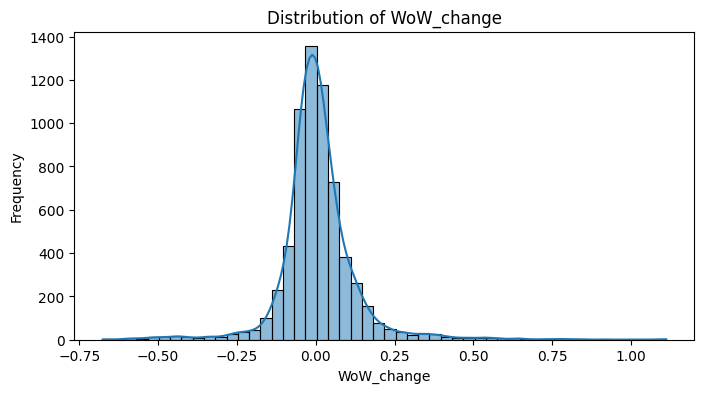

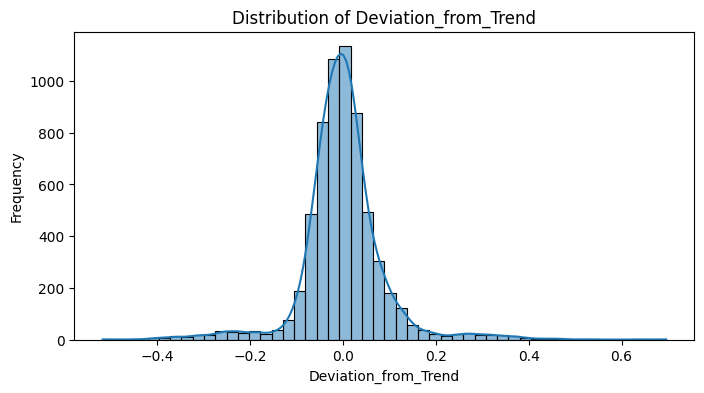

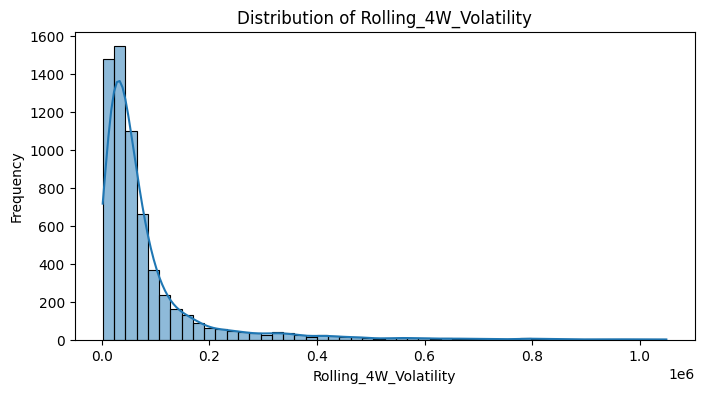

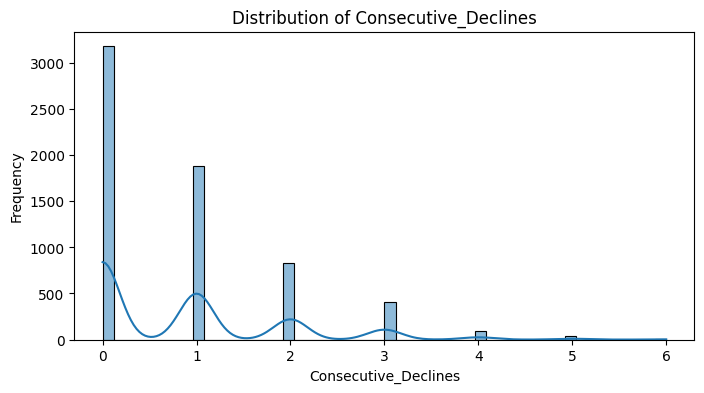

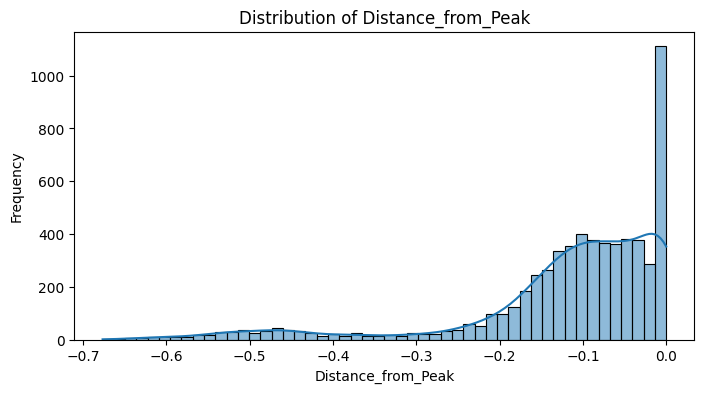

In [30]:
risk_indicators = [
    "WoW_change",
    "Deviation_from_Trend",
    "Rolling_4W_Volatility",
    "Consecutive_Declines",
    "Distance_from_Peak"
]

plot_distribution(df_store, risk_indicators)